<a href="https://colab.research.google.com/github/muthyalasairam6/ML-PROJECTS/blob/main/Kidney_Stone_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================
# Import Required Libraries
# ============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kidney-stone-dataset.csv to kidney-stone-dataset.csv


In [ ]:
df = pd.read_csv("kidney-stone-dataset.csv")

In [ ]:
df.head()

,Unnamed: 0,gravity,ph,osmo,cond,urea,calc,target
0,0,1.021,4.91,725,14.0,443,2.45,0
1,1,1.017,5.74,577,20.0,296,4.49,0
2,2,1.008,7.20,321,14.9,101,2.36,0
3,3,1.011,5.51,408,12.6,224,2.15,0
4,4,1.005,6.52,187,7.5,91,1.16,0


In [ ]:
print(df.shape)

(90, 8)


In [ ]:
print(df.shape)

(90, 8)


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'gravity', 'ph', 'osmo', 'cond', 'urea', 'calc',
       'target'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  90 non-null     int64  
 1   gravity     90 non-null     float64
 2   ph          90 non-null     float64
 3   osmo        90 non-null     int64  
 4   cond        90 non-null     float64
 5   urea        90 non-null     int64  
 6   calc        90 non-null     float64
 7   target      90 non-null     int64  
dtypes: float64(4), int64(4)
memory usage: 5.8 KB


In [ ]:
df.describe()

,Unnamed: 0,gravity,ph,osmo,cond,urea,calc,target
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,44.500000,1.017952,6.036651,602.333333,20.621687,258.200000,4.017788,0.500000
std,26.124701,0.006780,0.711801,238.459805,7.654448,135.381127,3.016273,0.502801
min,0.000000,1.005000,4.760000,187.000000,5.100000,10.000000,0.170000,0.000000
25%,22.250000,1.012258,5.536520,411.500000,14.150000,148.250000,1.412500,0.000000
50%,44.500000,1.018000,5.936247,572.000000,21.177172,231.500000,3.230000,0.500000
75%,66.750000,1.023000,6.490000,778.000000,26.075000,366.250000,5.965127,1.000000
max,89.000000,1.034000,7.940000,1236.000000,38.000000,620.000000,13.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
gravity,0
ph,0
osmo,0
cond,0
urea,0
calc,0
target,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df["target"].value_counts()

,count
target,
0,45
1,45


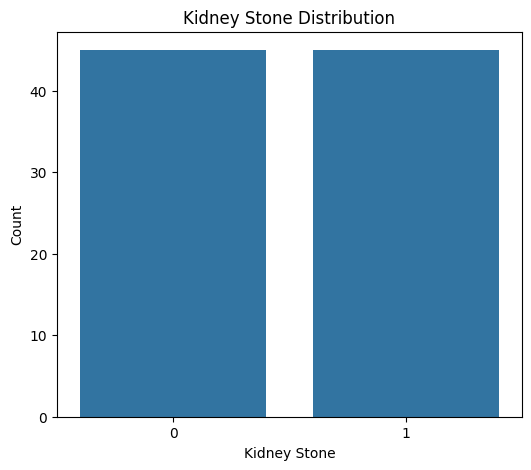

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x="target", data=df)

plt.title("Kidney Stone Distribution")

plt.xlabel("Kidney Stone")

plt.ylabel("Count")

plt.show()

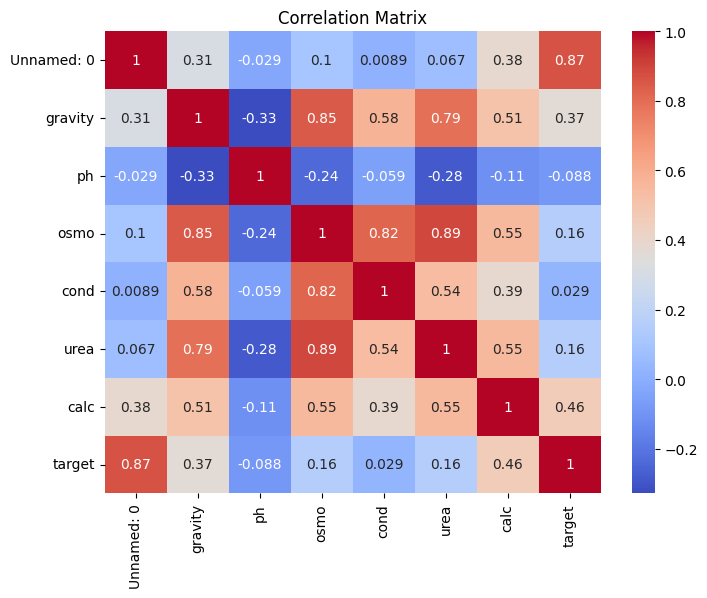

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [ ]:
X = df.drop("target", axis=1)

y = df["target"]

In [ ]:
print(X.shape)

print(y.shape)

(90, 7)
(90,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)

print(X_test.shape)

(72, 7)
(18, 7)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
results = []

In [ ]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
log_pred = log_model.predict(X_test)

log_prob = log_model.predict_proba(X_test)[:,1]

In [ ]:
log_accuracy = accuracy_score(y_test, log_pred)

log_precision = precision_score(y_test, log_pred)

log_recall = recall_score(y_test, log_pred)

log_f1 = f1_score(y_test, log_pred)

log_roc = roc_auc_score(y_test, log_prob)

print("Accuracy :", log_accuracy)

print("Precision :", log_precision)

print("Recall :", log_recall)

print("F1 Score :", log_f1)

print("ROC AUC :", log_roc)

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
ROC AUC : 1.0


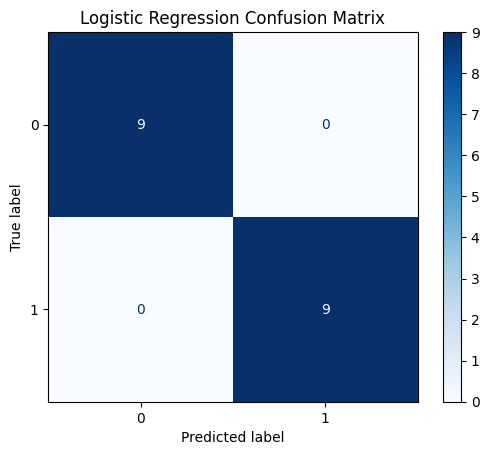

In [ ]:
cm = confusion_matrix(y_test, log_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
results.append([
    "Logistic Regression",
    log_accuracy,
    log_precision,
    log_recall,
    log_f1,
    log_roc
])

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_roc = roc_auc_score(y_test, rf_prob)

print("Accuracy :", rf_accuracy)

print("Precision :", rf_precision)

print("Recall :", rf_recall)

print("F1 Score :", rf_f1)

print("ROC AUC :", rf_roc)

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
ROC AUC : 1.0


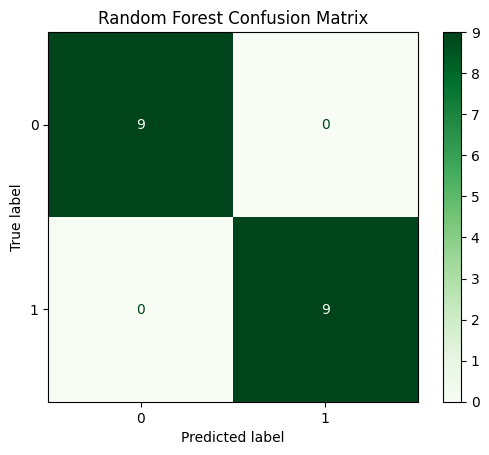

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
results.append([
    "Random Forest",
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_roc
])

In [ ]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

xgb_precision = precision_score(y_test, xgb_pred)

xgb_recall = recall_score(y_test, xgb_pred)

xgb_f1 = f1_score(y_test, xgb_pred)

xgb_roc = roc_auc_score(y_test, xgb_prob)

print("Accuracy :", xgb_accuracy)

print("Precision :", xgb_precision)

print("Recall :", xgb_recall)

print("F1 Score :", xgb_f1)

print("ROC AUC :", xgb_roc)

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
ROC AUC : 1.0


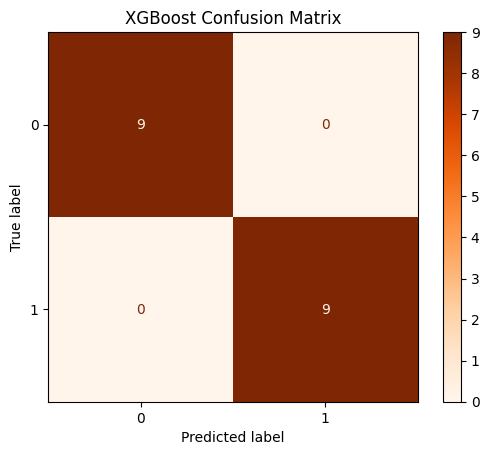

In [ ]:
cm = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Oranges")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [ ]:
results.append([
    "XGBoost",
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1,
    xgb_roc
])

In [ ]:
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [ ]:
svm_pred = svm_model.predict(X_test)

svm_prob = svm_model.predict_proba(X_test)[:,1]

In [ ]:
svm_accuracy = accuracy_score(y_test, svm_pred)

svm_precision = precision_score(y_test, svm_pred)

svm_recall = recall_score(y_test, svm_pred)

svm_f1 = f1_score(y_test, svm_pred)

svm_roc = roc_auc_score(y_test, svm_prob)

print("Accuracy :", svm_accuracy)
print("Precision :", svm_precision)
print("Recall :", svm_recall)
print("F1 Score :", svm_f1)
print("ROC AUC :", svm_roc)

Accuracy : 0.8888888888888888
Precision : 0.8888888888888888
Recall : 0.8888888888888888
F1 Score : 0.8888888888888888
ROC AUC : 0.962962962962963


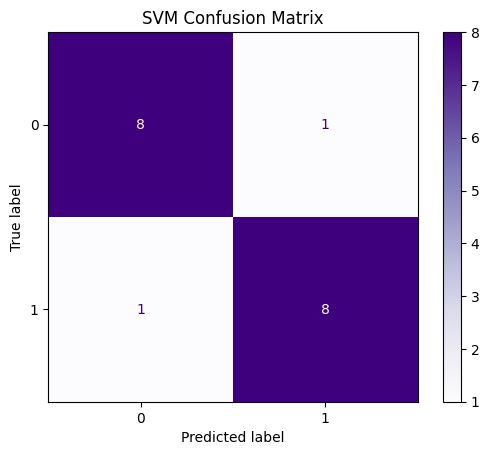

In [ ]:
cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Purples")

plt.title("SVM Confusion Matrix")

plt.show()

In [ ]:
results.append([
    "SVM",
    svm_accuracy,
    svm_precision,
    svm_recall,
    svm_f1,
    svm_roc
])

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
knn_pred = knn_model.predict(X_test)

knn_prob = knn_model.predict_proba(X_test)[:,1]

In [ ]:
knn_accuracy = accuracy_score(y_test, knn_pred)

knn_precision = precision_score(y_test, knn_pred)

knn_recall = recall_score(y_test, knn_pred)

knn_f1 = f1_score(y_test, knn_pred)

knn_roc = roc_auc_score(y_test, knn_prob)

print("Accuracy :", knn_accuracy)
print("Precision :", knn_precision)
print("Recall :", knn_recall)
print("F1 Score :", knn_f1)
print("ROC AUC :", knn_roc)

Accuracy : 0.8333333333333334
Precision : 0.875
Recall : 0.7777777777777778
F1 Score : 0.8235294117647058
ROC AUC : 0.8641975308641976


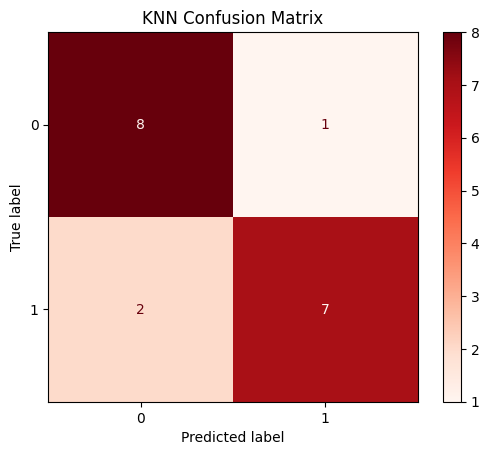

In [ ]:
cm = confusion_matrix(y_test, knn_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Reds")

plt.title("KNN Confusion Matrix")

plt.show()

In [ ]:
results.append([
    "KNN",
    knn_accuracy,
    knn_precision,
    knn_recall,
    knn_f1,
    knn_roc
])

In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=1000,
    random_state=42
)

mlp_model.fit(X_train, y_train)

MLPClassifier(max_iter=1000, random_state=42)

In [ ]:
mlp_pred = mlp_model.predict(X_test)

mlp_prob = mlp_model.predict_proba(X_test)[:,1]

In [ ]:
mlp_accuracy = accuracy_score(y_test, mlp_pred)

mlp_precision = precision_score(y_test, mlp_pred)

mlp_recall = recall_score(y_test, mlp_pred)

mlp_f1 = f1_score(y_test, mlp_pred)

mlp_roc = roc_auc_score(y_test, mlp_prob)

print("Accuracy :", mlp_accuracy)
print("Precision :", mlp_precision)
print("Recall :", mlp_recall)
print("F1 Score :", mlp_f1)
print("ROC AUC :", mlp_roc)

Accuracy : 0.9444444444444444
Precision : 1.0
Recall : 0.8888888888888888
F1 Score : 0.9411764705882353
ROC AUC : 1.0


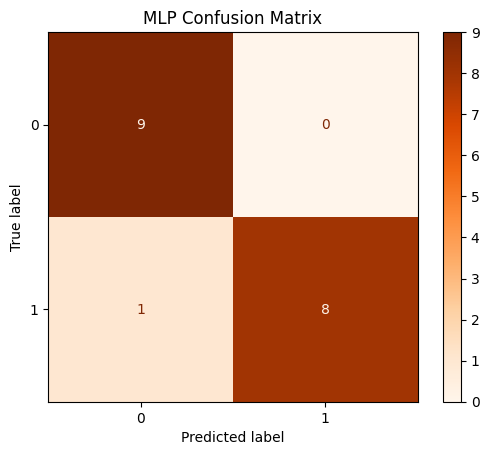

In [ ]:
cm = confusion_matrix(y_test, mlp_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Oranges")

plt.title("MLP Confusion Matrix")

plt.show()

In [ ]:
results.append([
    "MLP",
    mlp_accuracy,
    mlp_precision,
    mlp_recall,
    mlp_f1,
    mlp_roc
])

In [ ]:
result_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

result_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
2,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
3,SVM,0.888889,0.888889,0.888889,0.888889,0.962963
4,KNN,0.833333,0.875000,0.777778,0.823529,0.864198
5,MLP,0.944444,1.000000,0.888889,0.941176,1.000000


In [ ]:
result_df = result_df.sort_values(
    by="Accuracy",
    ascending=False
)

result_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
2,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
5,MLP,0.944444,1.000000,0.888889,0.941176,1.000000
3,SVM,0.888889,0.888889,0.888889,0.888889,0.962963
4,KNN,0.833333,0.875000,0.777778,0.823529,0.864198


In [ ]:
best_model_name = result_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


In [ ]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "SVM": svm_model,
    "KNN": knn_model,
    "MLP": mlp_model
}

best_model = models[best_model_name]

print("Best Model Selected:", best_model_name)

Best Model Selected: Logistic Regression


In [ ]:
best_pred = best_model.predict(X_test)

best_prob = best_model.predict_proba(X_test)[:,1]

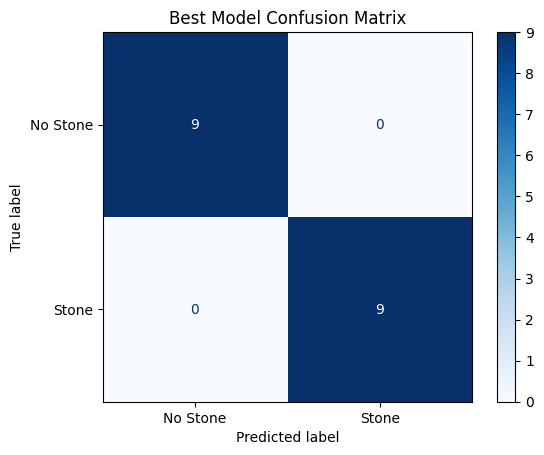

In [ ]:
cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Stone","Stone"]
)

disp.plot(cmap="Blues")

plt.title("Best Model Confusion Matrix")

plt.show()

In [ ]:
print("========== FINAL RESULT ==========")

print("Model      :", best_model_name)

print("Accuracy   :", accuracy_score(y_test,best_pred))

print("Precision  :", precision_score(y_test,best_pred))

print("Recall     :", recall_score(y_test,best_pred))

print("F1 Score   :", f1_score(y_test,best_pred))

print("ROC AUC    :", roc_auc_score(y_test,best_prob))

========== FINAL RESULT ==========
Model      : Logistic Regression
Accuracy   : 1.0
Precision  : 1.0
Recall     : 1.0
F1 Score   : 1.0
ROC AUC    : 1.0


In [ ]:
import joblib

joblib.dump(best_model,"kidney_stone_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
joblib.dump(scaler,"scaler.pkl")

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [ ]:
from google.colab import files

files.download("kidney_stone_model.pkl")

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sample = X_test[0].reshape(1,-1)

prediction = best_model.predict(sample)

print(prediction)

[1]
